In [2]:
!pip install finpy-tse pandas numpy matplotlib seaborn scipy statsmodels


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import finpy_tse as fse

# تنظیمات بصری نمودارها
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ۱. دریافت دیتای تعدیل‌شده سهم فملی
print("در حال دریافت دیتای فملی...")
fameli = fse.Get_Price_History(
    stock='فملی',
    start_date='1400-01-01',
    end_date='1403-01-01',
    ignore_date=False,
    adjust_price=True
)

# ۲. دریافت دیتای تعدیل‌شده سهم فولاد
print("در حال دریافت دیتای فولاد...")
foolad = fse.Get_Price_History(
    stock='فولاد',
    start_date='1400-01-01',
    end_date='1403-01-01',
    ignore_date=False,
    adjust_price=True
)

# ۳. دریافت دیتای شاخص کل (Market Index)
print("در حال دریافت دیتای شاخص کل...")
index_data = fse.Get_CWI_History(
    start_date='1400-01-01',
    end_date='1403-01-01',
    ignore_date=False
)

# ساخت دیتافریم یکپارچه از قیمت‌های پایانی
df_prices = pd.DataFrame({
    'Fameli': fameli['Adj Close'],
    'Foolad': foolad['Adj Close'],
    'Market': index_data['Close']
}).dropna()

print("\n۵ سطر اول قیمت‌های پایانی تعدیل‌شده:")
df_prices.head()


در حال دریافت دیتای فملی...


C:\Users\TANIN-TCC\Anaconda3\Lib\site-packages\finpy_tse\__init__.py:424: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_history = pd.concat([df_history,df_temp])


در حال دریافت دیتای فولاد...


C:\Users\TANIN-TCC\Anaconda3\Lib\site-packages\finpy_tse\__init__.py:424: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_history = pd.concat([df_history,df_temp])


در حال دریافت دیتای شاخص کل...

۵ سطر اول قیمت‌های پایانی تعدیل‌شده:


,Fameli,Foolad,Market
J-Date,,,
1400-01-07,1314.0,912.0,1309573.0
1400-01-08,1296.0,903.0,1306859.0
1400-01-10,1280.0,913.0,1303089.0
1400-01-11,1257.0,898.0,1294544.0
1400-01-14,1236.0,884.0,1282874.0


In [4]:
df_prices.tail()

,Fameli,Foolad,Market
J-Date,,,
1402-12-22,2936.0,2164.0,2163479.0
1402-12-23,2960.0,2133.0,2150035.0
1402-12-26,3041.0,2147.0,2148494.0
1402-12-27,3145.0,2224.0,2160406.0
1402-12-28,3265.0,2291.0,2195092.0


In [5]:
# محاسبه بازدهی ساده روزانه (Simple Daily Returns)
df_returns = df_prices.pct_change().dropna() * 100  # بر حسب درصد
df_returns.columns = ['Fameli_Return', 'Foolad_Return', 'Market_Return']

print("آمار توصیفی بازدهی‌ها (میانگین، انحراف معیار و ...):")
df_returns.describe()


آمار توصیفی بازدهی‌ها (میانگین، انحراف معیار و ...):


,Fameli_Return,Foolad_Return,Market_Return
count,652.000000,652.000000,652.000000
mean,0.161775,0.164276,0.087266
std,2.121075,2.151739,1.269566
min,-9.553641,-7.692308,-5.802123
25%,-0.932351,-0.992992,-0.506918
50%,0.000000,-0.043290,0.024025
75%,0.861482,1.013465,0.615640
max,16.940639,11.561743,7.910708


In [6]:
import statsmodels.api as sm

# رگرسیون برای هر سهم نسبت به بازار
def calculate_beta(stock_returns, market_returns, name):
    X = sm.add_constant(market_returns)   # افزودن عرض از مبدأ (آلفا)
    model = sm.OLS(stock_returns, X).fit()
    alpha = model.params.iloc[0]
    beta  = model.params.iloc[1]
    print(f"—— {name} ——")
    print(f"Alpha: {alpha:.4f} | Beta: {beta:.3f} | R-squared: {model.rsquared:.3f}\n")
    return model

model_fameli = calculate_beta(df_returns['Fameli_Return'], df_returns['Market_Return'], "فملی")
model_foolad = calculate_beta(df_returns['Foolad_Return'], df_returns['Market_Return'], "فولاد")


—— فملی ——
Alpha: 0.0558 | Beta: 1.214 | R-squared: 0.528

—— فولاد ——
Alpha: 0.0572 | Beta: 1.227 | R-squared: 0.524



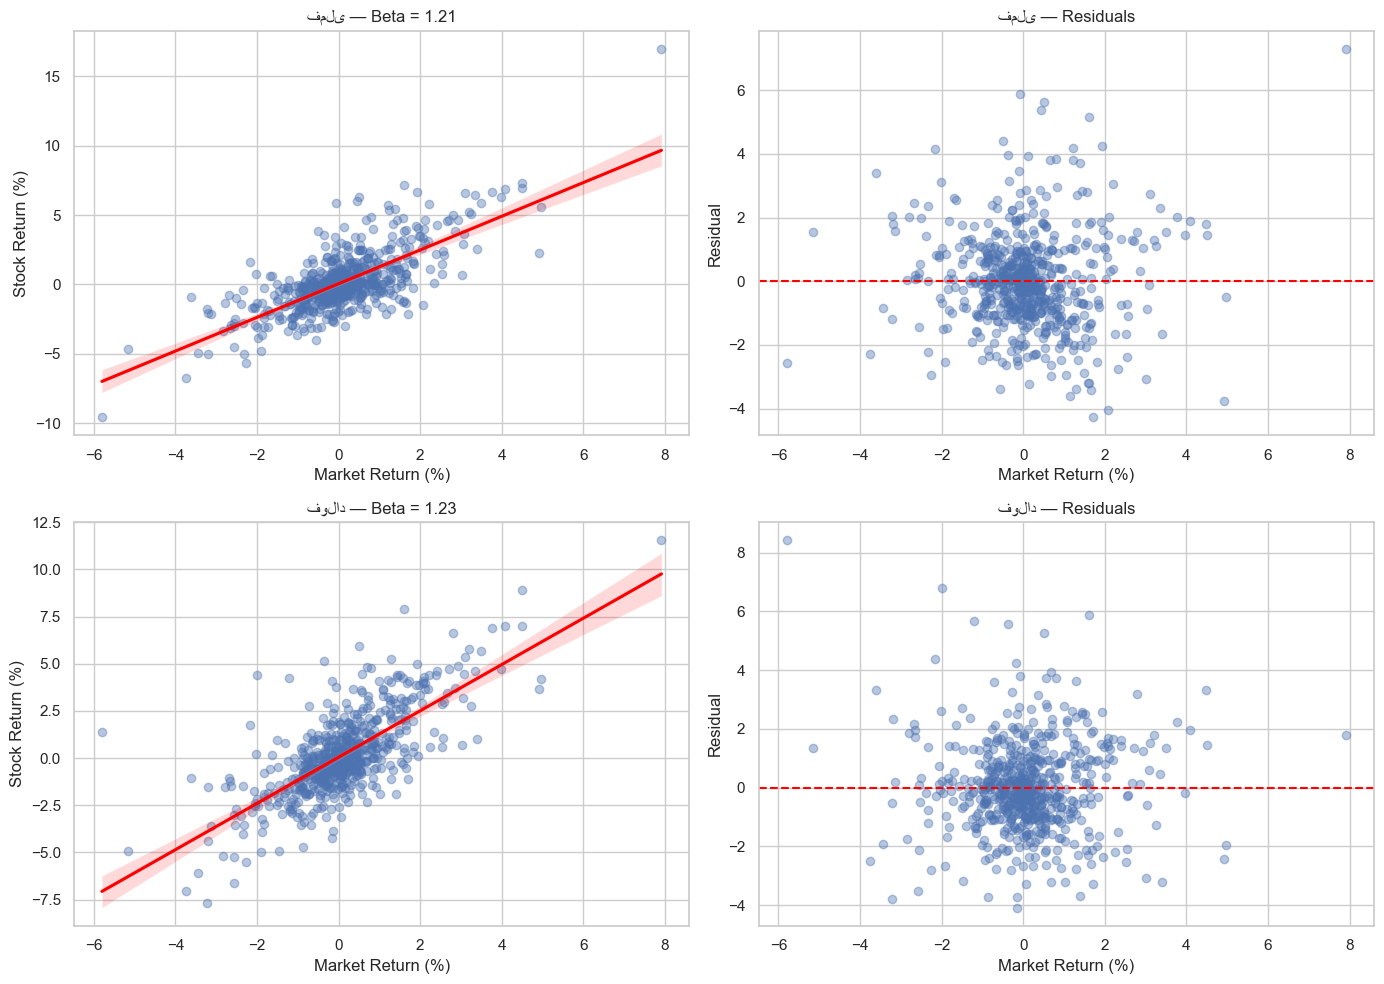

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stocks = [('Fameli_Return', model_fameli, 'فملی'),
          ('Foolad_Return', model_foolad, 'فولاد')]

for i, (col, model, name) in enumerate(stocks):
    # نمودار پراکندگی و خط رگرسیون
    ax = axes[i][0]
    sns.regplot(x=df_returns['Market_Return'], y=df_returns[col],
                ax=ax, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    ax.set_title(f'{name} — Beta = {model.params.iloc[1]:.2f}')
    ax.set_xlabel('Market Return (%)'); ax.set_ylabel('Stock Return (%)')

    # نمودار باقیمانده‌ها (Residuals)
    ax2 = axes[i][1]
    ax2.scatter(df_returns['Market_Return'], model.resid, alpha=0.4)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_title(f'{name} — Residuals')
    ax2.set_xlabel('Market Return (%)'); ax2.set_ylabel('Residual')

plt.tight_layout()
plt.show()


—— شاخص‌های شکل توزیع بازدهی‌ها ——
Fameli_Return: Skewness = 1.237 | Excess Kurtosis = 7.433
Foolad_Return: Skewness = 0.602 | Excess Kurtosis = 2.417
Market_Return: Skewness = 0.445 | Excess Kurtosis = 4.319


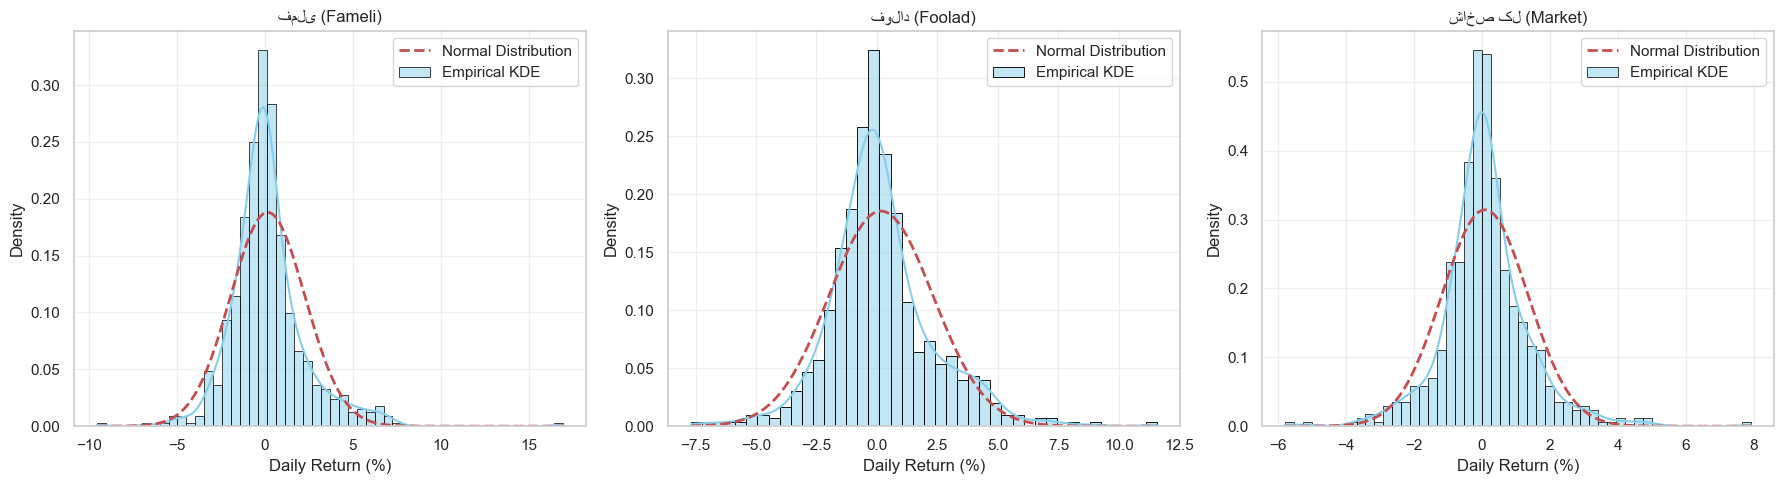

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# محاسبه چولگی (Skewness) و کشیدگی اضافی (Excess Kurtosis)
print("—— شاخص‌های شکل توزیع بازدهی‌ها ——")
for col in df_returns.columns:
    skew = stats.skew(df_returns[col])
    kurt = stats.kurtosis(df_returns[col]) # پیش‌فرض scipy کشیدگی اضافی (Excess Kurtosis) است
    print(f"{col}: Skewness = {skew:.3f} | Excess Kurtosis = {kurt:.3f}")

# رسم نمودار هیستوگرام همراه با منحنی تخمین چگالی (KDE) و منحنی نرمال نظری
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['فملی (Fameli)', 'فولاد (Foolad)', 'شاخص کل (Market)']

for ax, col, title in zip(axes, df_returns.columns, titles):
    data = df_returns[col]
    
    # هیستوگرام و منحنی تجربی داده‌ها
    sns.histplot(data, kde=True, stat="density", ax=ax, color='skyblue', edgecolor='black', alpha=0.5, label='Empirical KDE')
    
    # برازش و رسم توزیع نرمال متناظر (با همان میانگین و انحراف معیار)
    mu, std = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    p = stats.norm.pdf(x, mu, std)
    ax.plot(x, p, 'r--', linewidth=2, label='Normal Distribution')
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
print("================== گزارش رگرسیون فملی ==================")
print(model_fameli.summary())

print("\n================== گزارش رگرسیون فولاد ==================")
print(model_foolad.summary())


================== گزارش رگرسیون فملی ==================
                            OLS Regression Results                            
Dep. Variable:          Fameli_Return   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     727.0
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          4.70e-108
Time:                        07:10:28   Log-Likelihood:                -1170.2
No. Observations:                 652   AIC:                             2344.
Df Residuals:                     650   BIC:                             2353.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

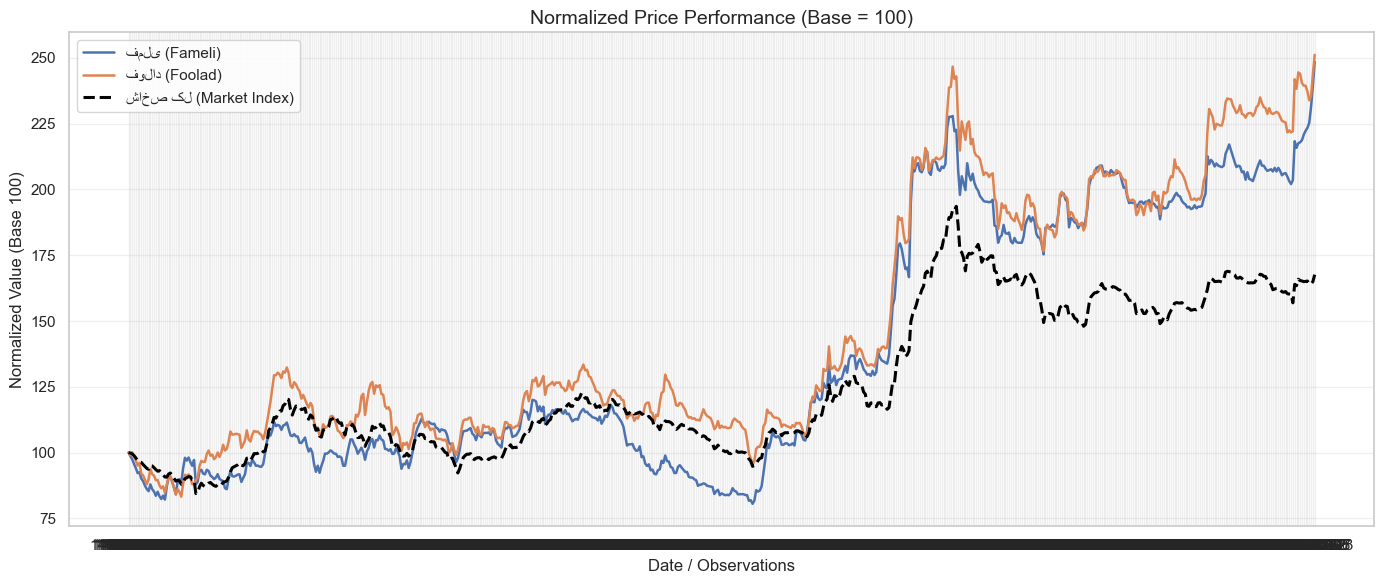

In [10]:
# نرمال‌سازی قیمت‌ها با پایه ۱۰۰ در روز اول نمونه
df_normalized = (df_prices / df_prices.iloc[0]) * 100

plt.figure(figsize=(14, 6))
plt.plot(df_normalized.index, df_normalized.iloc[:, 0], label='فملی (Fameli)', linewidth=1.8)
plt.plot(df_normalized.index, df_normalized.iloc[:, 1], label='فولاد (Foolad)', linewidth=1.8)
plt.plot(df_normalized.index, df_normalized.iloc[:, 2], label='شاخص کل (Market Index)', linewidth=2.2, color='black', linestyle='--')

plt.title('Normalized Price Performance (Base = 100)', fontsize=14)
plt.xlabel('Date / Observations')
plt.ylabel('Normalized Value (Base 100)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


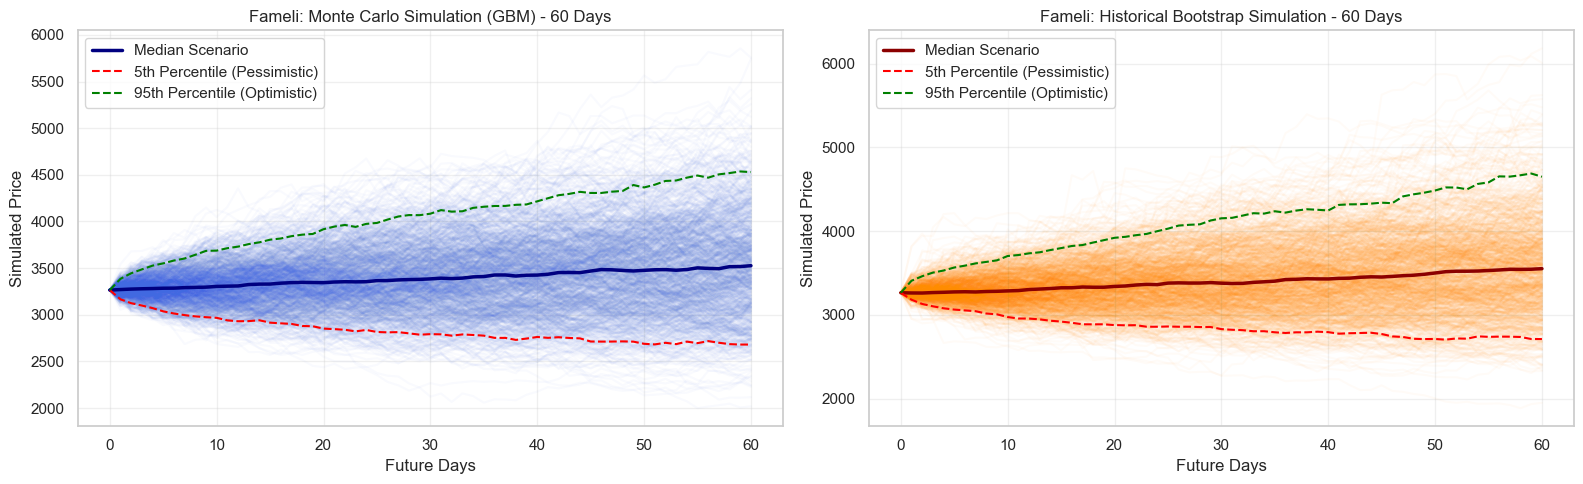

================== پیش‌بینی سناریویی قیمت فملی در روز ۶۰ ==================
آخرین قیمت واقعی: 3,265
مونت‌کارلو (GBM)  -> بدبینانه (صدک ۵): 2,681 | میانه: 3,526 | خوش‌بینانه (صدک ۹۵): 4,529
بوت‌استرپ تجربی   -> بدبینانه (صدک ۵): 2,712 | میانه: 3,552 | خوش‌بینانه (صدک ۹۵): 4,650


In [11]:
import numpy as np

# تنظیم پارامترهای شبیه‌سازی
n_simulations = 1000   # تعداد سناریوها
n_days = 60            # افق زمانی (روزهای کاری پیش‌رو)
np.random.seed(42)      # برای تکرارپذیری نتایج

# محاسبه بازده لگاریتمی روزانه برای شبیه‌سازی دقیق‌تر هندسی
log_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# آخرین قیمت‌های واقعی موجود در دیتا
last_price_fameli = df_prices['Fameli'].iloc[-1]
last_price_foolad = df_prices['Foolad'].iloc[-1]

# -------------------------------------------------------------
# ۱. شبیه‌سازی مونت‌کارلو پارامتریک (GBM)
# -------------------------------------------------------------
def run_monte_carlo(last_price, series_returns, n_days, n_simulations):
    mu = series_returns.mean()
    sigma = series_returns.std()
    # فرمول حرکت براونی هندسی با تعدیل دریفت: (mu - 0.5 * sigma^2) + sigma * Z
    drift = mu - 0.5 * (sigma ** 2)
    daily_shocks = np.random.normal(drift, sigma, (n_days, n_simulations))
    price_paths = np.zeros((n_days + 1, n_simulations))
    price_paths[0] = last_price
    for t in range(1, n_days + 1):
        price_paths[t] = price_paths[t-1] * np.exp(daily_shocks[t-1])
    return price_paths

mc_fameli = run_monte_carlo(last_price_fameli, log_returns['Fameli'], n_days, n_simulations)
mc_foolad = run_monte_carlo(last_price_foolad, log_returns['Foolad'], n_days, n_simulations)

# -------------------------------------------------------------
# ۲. شبیه‌سازی بوت‌استرپ ناپارامتریک (Historical Bootstrap)
# -------------------------------------------------------------
def run_bootstrap(last_price, series_returns, n_days, n_simulations):
    # انتخاب تصادفی بازده‌ها از تاریخچه واقعی سهم (با جایگذاری)
    sampled_returns = np.random.choice(series_returns, size=(n_days, n_simulations), replace=True)
    price_paths = np.zeros((n_days + 1, n_simulations))
    price_paths[0] = last_price
    for t in range(1, n_days + 1):
        price_paths[t] = price_paths[t-1] * np.exp(sampled_returns[t-1])
    return price_paths

boot_fameli = run_bootstrap(last_price_fameli, log_returns['Fameli'], n_days, n_simulations)
boot_foolad = run_bootstrap(last_price_foolad, log_returns['Foolad'], n_days, n_simulations)

# -------------------------------------------------------------
# رسم نمودارهای شبیه‌سازی برای فملی
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# نمودار مونت‌کارلو فملی
axes[0].plot(mc_fameli, color='royalblue', alpha=0.03)
axes[0].plot(np.median(mc_fameli, axis=1), color='navy', linewidth=2.5, label='Median Scenario')
axes[0].plot(np.percentile(mc_fameli, 5, axis=1), color='red', linestyle='--', linewidth=1.5, label='5th Percentile (Pessimistic)')
axes[0].plot(np.percentile(mc_fameli, 95, axis=1), color='green', linestyle='--', linewidth=1.5, label='95th Percentile (Optimistic)')
axes[0].set_title('Fameli: Monte Carlo Simulation (GBM) - 60 Days', fontsize=12)
axes[0].set_xlabel('Future Days')
axes[0].set_ylabel('Simulated Price')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# نمودار بوت‌استرپ فملی
axes[1].plot(boot_fameli, color='darkorange', alpha=0.03)
axes[1].plot(np.median(boot_fameli, axis=1), color='darkred', linewidth=2.5, label='Median Scenario')
axes[1].plot(np.percentile(boot_fameli, 5, axis=1), color='red', linestyle='--', linewidth=1.5, label='5th Percentile (Pessimistic)')
axes[1].plot(np.percentile(boot_fameli, 95, axis=1), color='green', linestyle='--', linewidth=1.5, label='95th Percentile (Optimistic)')
axes[1].set_title('Fameli: Historical Bootstrap Simulation - 60 Days', fontsize=12)
axes[1].set_xlabel('Future Days')
axes[1].set_ylabel('Simulated Price')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# چاپ فواصل اطمینان و سناریوهای آماری قیمت پایان دوره (روز ۶۰)
# -------------------------------------------------------------
print("================== پیش‌بینی سناریویی قیمت فملی در روز ۶۰ ==================")
print(f"آخرین قیمت واقعی: {last_price_fameli:,.0f}")
print(f"مونت‌کارلو (GBM)  -> بدبینانه (صدک ۵): {np.percentile(mc_fameli[-1], 5):,.0f} | میانه: {np.median(mc_fameli[-1]):,.0f} | خوش‌بینانه (صدک ۹۵): {np.percentile(mc_fameli[-1], 95):,.0f}")
print(f"بوت‌استرپ تجربی   -> بدبینانه (صدک ۵): {np.percentile(boot_fameli[-1], 5):,.0f} | میانه: {np.median(boot_fameli[-1]):,.0f} | خوش‌بینانه (صدک ۹۵): {np.percentile(boot_fameli[-1], 95):,.0f}")
